**Uczenie Głębokie (laboratorium)**

Dominik Filipiak

`df[🏒]amu.edu.pl`

Materiały są przygotowane na podstawie zmodyfikowanych materiałów dr. Pawła Skórzewskiego oraz dr. Wojciecha Kowalewskiego.

# Regresja logistyczna. Walidacja krzyżowa. Techniki ewaluacji modelu.

1. Pierwszym celem jest ugruntowanie wiedzy o technikach klasyfikacji binarnej na podstawie metody regresji logistycznej.
2. Celem drugim jest wprowadzenie (bądź przypomnienie) kilku istotnych elementów ewaluacji jakości budowanego modelu: walidacja krzyżowa i różne wielkości oceny jakości
3. Zadanie do samodzielnego rozwiązania:
    - Pobierz dane bazy [`plantvillage-dataset`](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset)
    - Posługując się plikami `03_Regresja_logistyczna.ipynb`, `04_Metody_ewaluacji.ipynb` oraz przykładem klasyfikacji obrazowej na stronie [`logistic-regression-for-image-classification`](https://scipython.com/blog/logistic-regression-for-image-classification/) (lub jakimś innym tego typu) przeprowadź klasyfikację binarną na trzech wybranych parach klas liści.
    - W każdym przypadku podziel zbiór obrazów danej pary klas na zbiór treningowy i testowy.
    - Zastosuj walidację krzyżową.
    - Oceń jakość przez obliczenie: accuracy, recall, precision oraz F1
    - Całość obliczeń przedstaw w postaci notatnika jupyter

## Regresja logistyczna

### Dane

**Uwaga**: Wbrew nazwie, *regresja* logistyczna jest algorytmem służącym do rozwiązywania problemów *klasyfikacji* (wcale nie problemów *regresji*!)

Do demonstracji metody regresji ligistycznej wykorzystamy klasyczny zbiór danych <a href="https://en.wikipedia.org/wiki/Iris_flower_data_set">*Iris flower data set*</a>, składający się ze 150 przykładów wartości 4 cech dla 3 gatunków irysów (kosaćców).

#### *Iris flower data set*

* 150 przykładów
* 4 cechy
* 3 kategorie

| <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg/450px-Kosaciec_szczecinkowaty_Iris_setosa.jpg"> | <img style="float: right;" src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Iris_virginica.jpg/736px-Iris_virginica.jpg"> | <img style="float: right;" src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/27/Blue_Flag%2C_Ottawa.jpg/600px-Blue_Flag%2C_Ottawa.jpg"> |
| :--- | :--- | :--- |
| *Iris setosa* | *Iris virginica* | *Iris versicolor* |
| kosaciec szczecinkowy | kosaciec amerykański | kosaciec różnobarwny |


4 cechy:
 * długość działek kielicha (*sepal length*, `sl`)
 * szerokość działek kielicha (*sepal width*, `sw`)
 * długość płatka (*petal length*, `pl`)
 * szerokość płatka (*petal width*, `pw`)

### 2.1.1. Dwuklasowa regresja logistyczna

Zacznijmy od najprostszego przypadku:
 * ograniczmy się do **2** klas
 * ograniczmy się do **1** zmiennej

→ dwuklasowa regresja logistyczna jednej zmiennej

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
# import pandas
import pandas as pd

from typing import List, Tuple, Callable, Optional
from IPython.display import display, Math

matplotlib.style.use('dark_background')


### Definicje funkcji pomocnicznych

#### Wzory (regresja liniowa)
(Jeśli coś jest niezrozumiałe - sprawdź materiały z lab. 1)

In [2]:
def hypothesis_lm(theta: np.matrix, X: np.matrix) -> np.matrix:
    """Hipoteza dla regresji liniowej (lm - linear model).
    W ogólności i uproszczeniu określa spodziewany związek między parametrami modelu, zmiennymi objaśniającymi oraz zmienną objasnianią.
    W tym wypadku zakładamy, ze regresja liniowa opisuje związek między naszymi zmiennymi.

    Args:
        theta (np.matrix): Macierz parametrów modelu
        X (np.matrix): Macierz cech (zmienne objaśniające)

    Returns:
        np.matrix: Macierz estymowane wartości (wynik modelu)
    """
    return X * theta


def loss_lm(theta: np.matrix, X: np.matrix, y: np.matrix) -> float:
    """Funkcji kosztu/straty (ang. cost/loss/error function) dla regresji liniowej.
    W uproszczeniu odpowiada na pytanie jak bardzo się pomyliliśmy w estymacji.
    Jesli koszt jest równy 0, to nasza estymacja jest idealna (predykcja odpowiada stanowi faktycznemu).

    Args:
        theta (np.matrix): Macierz parametrów modelu (ang. parameters)
        X (np.matrix): Macierz cech (ang. features)
        y (np.matrix): Wektor zmiennej docelowej (ang. target variable)

    Returns:
        float:
            Wartość kosztu (ang. cost/loss/error).
    """
    m = len(y)
    J = 1.0 / (2.0 * m) * ((X * theta - y).T * ( X * theta - y))
    return J.item()


def loss_lm_derivative(theta: np.matrix, X: np.matrix, y: np.matrix) -> np.matrix:
    """Gradient funkcji kosztu dla regresji liniowej.

    Args:
        theta (np.matrix): Macierz parametrów modelu (ang. parameters)
        X (np.matrix): Macierz cech (ang. features)
        y (np.matrix): Wektor zmiennej docelowej (ang. target variable)

    Returns:
        np.matrix: Gradient funkcji kosztu (wektor pochodnych kosztu po parametrach modelu).
    """
    return 1.0 / len(y) * (X.T * (X * theta - y)) 


def gradient_descent_lm(
        J: Callable[..., float],
        dJ: Callable[..., np.matrix],
        theta: np.matrix,
        X: np.matrix,
        y: np.matrix,
        alpha: float=0.1,
        eps: float=10**-3
    ) -> Tuple[np.matrix, List]:
    """Algorytm gradientu prostego dla regresji liniowej.

    Args:
        J (callable): Funkcja kosztu (loss function)
        dJ (callable): Pochodzna funkcji kosztu (loss function derivative)
        theta (np.matrix): Macierz parametrów modelu - przedmiotem optymalizacji (ang. model parameters)
        X (np.matrix): Macierz cech (zmienne objaśniające, ang. features)
        y (np.matrix): Wektor klas (zmienne zależne, ang. target variable)
        alpha (float, optional): Współczynnik uczenia (hiperparametr, ang. learning rate). Defaults to 0.1.
        eps (float, optional): Kryterium stopu. Defaults to 10**-3.

    Returns:
        Tuple: 
            Parametry modelu oraz historia działania
    """
    current_cost = J(theta, X, y)
    logs = [[current_cost, theta]]
    while True:
        theta = theta - alpha * dJ(theta, X, y) # implementacja wzoru
        current_cost, prev_cost = J(theta, X, y), current_cost
        if current_cost > 10000:
            break
        if abs(prev_cost - current_cost) <= eps:
            break
        logs.append([current_cost, theta]) 
    return theta, logs


#### Rysowanie i wyświetlanie

In [3]:
def display_matrix(matrix: np.matrix, num_rows: int=3, round_digits: Optional[float] = 3) -> str:
    """Funkcja pomocnicza do renderowania macierzy w notebookach.
    Zwrócowną wartość wyświetlamy za pomocą `display(Math(display_matrix(...)))`.

    Args:
        matrix (np.matrix): Macierz do wyświetlenia.
        num_rows (int, optional): _description_. Defaults to 3.
        round_digits (Optional[float], optional): _description_. Defaults to 3.

    Returns:
        str: Kod LaTeX zawierający reprezentację macierzy. 
    """
    total_rows, total_cols = matrix.shape

    top_rows = matrix[:num_rows, :].tolist()

    latex_matrix = r"\begin{bmatrix} "
    
    round_or_wrap = lambda x, round_digits : '\\text{' + x + '}' if type(x) == str else round(x, round_digits)
            
    for row in top_rows:
        latex_matrix += " & ".join(map(str, [round_or_wrap(x, round_digits) for x in row])) + r" \\ "

    if total_rows > num_rows:
        latex_matrix += " & ".join([r"\vdots"] * total_cols) + r" \\ "

    if total_rows > num_rows + 1:
        last_row = matrix[-1, :].tolist()[0]
        latex_matrix += " & ".join(map(str, [round_or_wrap(x, round_digits) for x in last_row])) + r" \\ "

    latex_matrix += r"\end{bmatrix}"

    return latex_matrix


def plot_scatter(X: np.matrix, y: np.matrix, xlabel: str , ylabel: str) -> matplotlib.figure.Figure:
    """Rysuje wykres rozrzutu.

    Args:
        X (np.matrix): Macierz cech
        y (np.matrix): Zmienna docelowa.
        xlabel (str): Etykieta dla osi x
        ylabel (str): Etykieta dla osi y

    Returns:
        matplotlib.figure.Figure: Obiekt wykresu.
    """
    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

    ax.scatter([X[:, 1]], [y], s=50, label='Dane')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.margins(.05, .05)
    
    plt.ylim(y.min() - 1, y.max() + 1)
    plt.xlim(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1)
    
    return fig


def plot_regression(fig: matplotlib.figure.Figure, fun: Callable, theta: np.matrix, X: np.matrix):
    """Dodaje krzywą regresji do istniejącego wykresu.

    Args:
        fig (matplotlib.figure.Figure): Obiekt wykresu po którym rysujemy
        fun (Callable): Funkcja regresji
        theta (np.matrix): Macierz parametrów modelu
        X (np.matrix): Macierz cech
    """

    ax = fig.axes[0]
    x0 = np.min(X[:, 1]) - 1.0
    x1 = np.max(X[:, 1]) + 1.0
    L = [x0, x1]
    LX = np.matrix([1, x0, 1, x1]).reshape(2, 2)
    
    theta_0 = float(theta[0][0].item())
    theta_1 = float(theta[1][0].item())
    
    ax.plot(
        L,
        fun(theta, LX),
        linewidth='1',
        label=(
            r'$y={theta0:.2}{op}{theta1:.2}x$'.format(
                theta0=theta_0,
                theta1=theta_1 if theta_1 >= 0 else -theta_1,
                op='+' if theta_1 >= 0 else '-')))


def add_legend_to_plot(fig: matplotlib.figure.Figure):
    """Legenda wykresu"""
    ax = fig.axes[0]
    handles, labels = ax.get_legend_handles_labels()
    # try-except block is a fix for a bug in Poly3DCollection
    try:
        fig.legend(handles, labels, fontsize='15', loc='lower right')
    except AttributeError:
        pass


def add_threshold_to_plot(fig: matplotlib.figure.Figure, theta: np.matrix):
    """Dodaje próg do wykresu na podstawie parametrów modelu.

    Args:
        fig (matplotlib.figure.Figure): Wykres do którego checmy dodać próg.
        theta (np.matrix): Parametry modelu, na podstawie których obliczmy próg.
    """
    x_thr = (0.5 - theta.item(0)) / theta.item(1)
    ax = fig.axes[0]
    ax.plot(
        [x_thr, x_thr],
        [-1, 2],
        color='orange',
        linestyle='dashed',
        label=u'próg: $x={:.2F}$'.format(x_thr)
        )


def plot_learning_curve(logs: List[Tuple[float, np.ndarray]]):
    """Rysuję krzywą uczenia się.

    Args:
        logs (List[Tuple[float, np.ndarray]]): Log jako lista krotek (koszt, macierz parametrów)
    """
    plt.figure(figsize=(8, 4))
    plt.plot([x[0] for x in logs])

    plt.title('Krzywa uczenia')
    plt.ylabel('Koszt $J$')
    plt.xlabel('Krok')
    
    plt.show()

 
def display_logs(logs: List[Tuple[float, np.ndarray]], display_every_nth: int = 100):
    """Wyświetla log wartości dla kosztu i parametrów modelu.

    Args:
        logs (List[Tuple[float, np.ndarray]]): Log jako lista krotek (koszt, macierz parametrów)
        display_every_nth (int, optional): Co ile kroków wyświetlic log. Defaults to 100.
    """
    for i, (current_cost, current_theta) in enumerate(logs):
        if i % display_every_nth == 0:
            step = f'{i:0>4}'
            display(Math(
                'J_{' + step + '}=' + f'{current_cost:.3f}\\quad '
                '\\theta_{' + step + '}=' + f'{display_matrix(current_theta)}'
            )
        )


### Przygotowanie danych (1 cecha, 2 klasy)

In [4]:
data_iris = pd.read_csv('iris.csv')

data_iris[:6]

,sl,sw,pl,pw,Gatunek
0,5.2,3.4,1.4,0.2,Iris-setosa
1,5.1,3.7,1.5,0.4,Iris-setosa
2,6.7,3.1,5.6,2.4,Iris-virginica
3,6.5,3.2,5.1,2.0,Iris-virginica
4,4.9,2.5,4.5,1.7,Iris-virginica
5,6.0,2.7,5.1,1.6,Iris-versicolor


In [5]:
data_iris_setosa = pd.DataFrame()
data_iris_setosa['dł. płatka'] = data_iris['pl']  # "pl" oznacza "petal length"
data_iris_setosa['Iris setosa?'] = data_iris['Gatunek'].apply(lambda x: 1 if x=='Iris-setosa' else 0)

data_iris_setosa[:6]

,dł. płatka,Iris setosa?
0,1.4,1
1,1.5,1
2,5.6,0
3,5.1,0
4,4.5,0
5,5.1,0


In [6]:
# m, liczba wierszy
m = data_iris_setosa.shape[0]

# X, macierz cech o wymiarachach m x 2
X = np.matrix(np.vstack([np.ones(m), data_iris_setosa.values[:, 0]]).T)

# y, m-elementowy wektor klas 
y = np.matrix(data_iris_setosa.values[:, 1]).reshape(m, 1)

display(
    Math('\mathbf{X}=' + f'{display_matrix(X)},' + '\quad \mathbf{y}=' + f'{display_matrix(y)}'),
    )

<IPython.core.display.Math object>

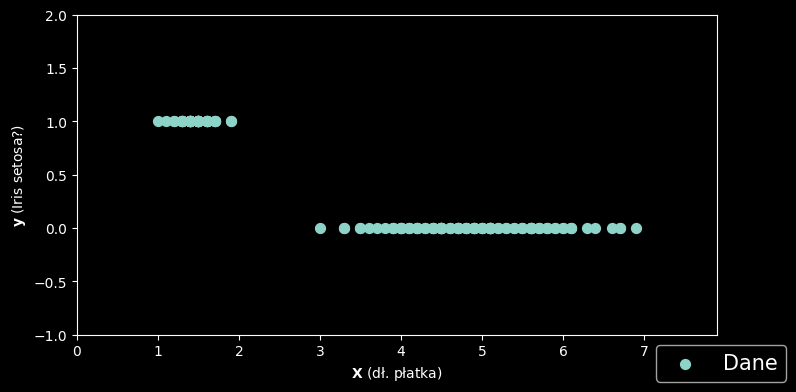

In [7]:
fig = plot_scatter(X, y, '$\mathbf{X}$ (dł. płatka)', '$\mathbf{y}$ (Iris setosa?)')
add_legend_to_plot(fig)

### Model - regresja liniowa

Najpierw z ciekawości sprawdźmy, co otrzymalibyśmy, gdybyśmy zastosowali regresję liniową do problemu klasyfikacji.

In [8]:
# Początkowa macierz parametrów naszego modelu
theta_start = np.matrix([0, 0]).reshape(2, 1)

Math('{\\theta_{\\text{start}}}=' + f'{display_matrix(theta_start)}')

<IPython.core.display.Math object>

In [9]:
# GD dla regresji liniowej
theta_linear_regression, logs_linear_regression = gradient_descent_lm(
    J=loss_lm,
    dJ=loss_lm_derivative,
    theta=theta_start,
    X=X,
    y=y,
    alpha=0.03,
    eps=0.000001,
)

# Nauczone parametry modelu
display(
    Math(
        '\\mathcal{L}= ' + f'{logs_linear_regression[-1][0]:.3f}, '
        f'\\quad \\theta={display_matrix(theta_linear_regression)}')
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

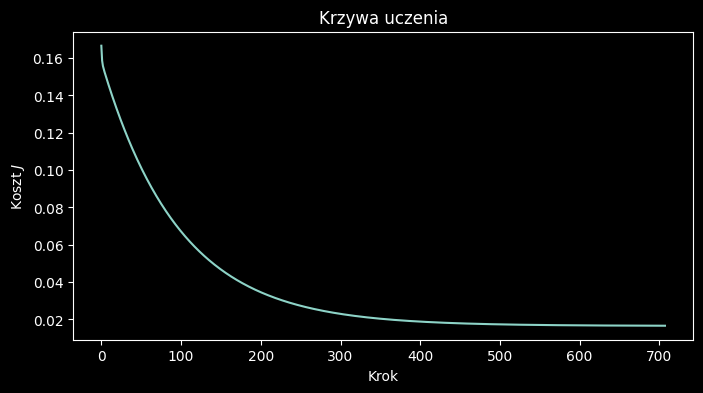

In [10]:
display_logs(logs_linear_regression)

plot_learning_curve(logs_linear_regression)


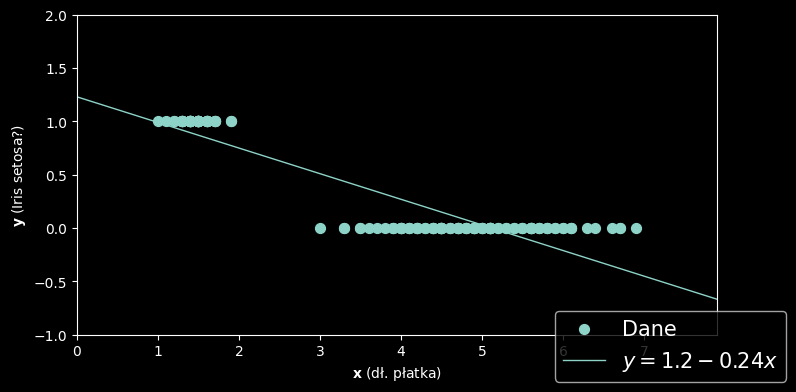

In [11]:
fig = plot_scatter(X, y, '$\mathbf{x}$ (dł. płatka)', '$\mathbf{y}$ (Iris setosa?)')
plot_regression(fig, hypothesis_lm, theta_linear_regression, X)
add_legend_to_plot(fig)

### Model - regresja liniowa z progiem

A gdyby tak przyjąć, że klasyfikator zwraca $1$ dla $h(x) > 0.5$ i $0$ w przeciwnym przypadku?

$$\text{threshold} = \frac{(0.5 - \theta_0)}{\theta_1}$$

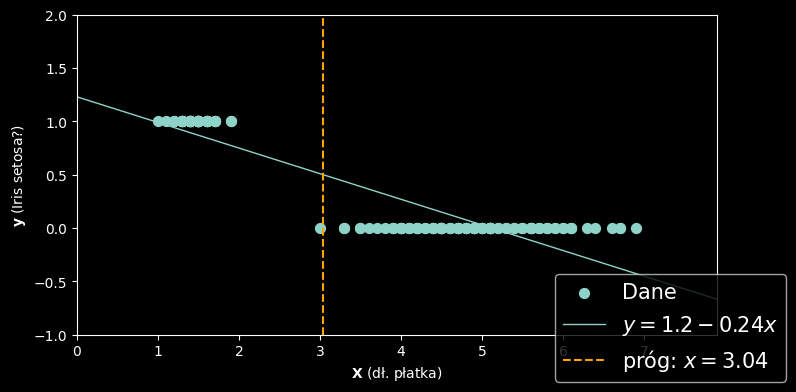

In [12]:
# pomarańczowa linia oznacza granicę między klasą "1" a klasą "0" wyznaczoną przez próg "h(x) = 0.5"
fig = plot_scatter(X, y, '$\mathbf{X}$ (dł. płatka)', '$\mathbf{y}$ (Iris setosa?)')
plot_regression(fig, hypothesis_lm, theta_linear_regression, X)
add_threshold_to_plot(fig, theta_linear_regression)
add_legend_to_plot(fig)

 * Krzywa regresji liniowej jest niezbyt dopasowana do danych klasyfikacyjnych.
 * Zastosowanie progu $y = 0.5$ nie zawsze pomaga uzyskać sensowny rezultat.
 * $h(x)$ może przyjmować wartości mniejsze od $0$ i większe od $1$ – jak interpretować takie wyniki?

Wniosek: w przypadku problemów klasyfikacyjnych regresja liniowa nie wydaje się najlepszym rozwiązaniem.

### Wprowadzenie do regresji logistycznej

#### Teoria

Wprowadźmy zatem pewne modyfikacje do naszego modelu.

Zdefiniujmy następującą funkcję, którą będziemy nazywać funkcją *logistyczną* (albo *sigmoidalną*):

**Funkcja logistyczna (sigmoidalna)**:

$$g(x) = \dfrac{1}{1+e^{-x}}$$

In [13]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """Funkcja logistyczna (sigmoidalna)"""
    return 1.0 / (1.0 + np.exp(-x))

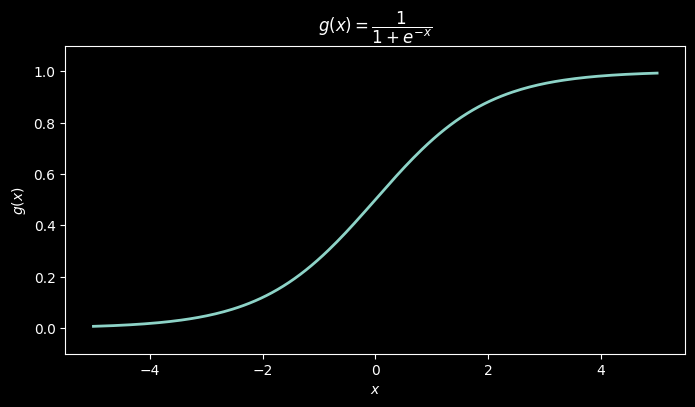

In [14]:
def plot_logistic():
    x = np.linspace(-5,5,200)
    y = sigmoid(x)

    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    plt.ylim(-.1,1.1)
    ax.plot(x, y, linewidth='2')

    plt.title('$g(x) = \dfrac{1}{1+e^{-x}}$')
    plt.ylabel('$g(x)$')
    plt.xlabel('$x$')

plot_logistic()

Funkcja logistyczna przekształca zbiór liczb rzeczywistych $\mathbb{R}$ w przedział otwarty $(0, 1)$.

Funkcja regresji logistycznej dla pojedynczego przykładu o cechach wyrażonych wektorem $x$:

$$h_{\boldsymbol{\theta}}(x) = g(x; \,\boldsymbol{\theta} ) = \dfrac{1}{1 + e^{-\boldsymbol{\theta}^T x}}$$

Dla całej macierzy cech $\mathbf{X}$:

$$h_{\boldsymbol{\theta}}(\mathbf{X}) = g(X; \,\boldsymbol{\theta}) = \dfrac{1}{1 + e^{-\mathbf{X} \boldsymbol{\theta}}}$$

Funkcja kosztu dla regresji logistycznej:

$$\mathcal{L} = J(\theta) = -\dfrac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log h_\theta( x^{(i)} ) + \left( 1 - y^{(i)} \right) \log \left( 1 - h_\theta (x^{(i)}) \right) \right)$$

Zasadniczo jest to entropia krzyzowa, ale do tego jeszcze dojdziemy.

Gradient dla regresji logistycznej (wersja macierzowa):

$$\nabla \mathcal{L} = \nabla J(\theta) = \frac{1}{|\mathbf{y}|} X^T \left( h_\theta(\mathbf{X}) - \mathbf{y} \right)$$

(Jedyna różnica między gradientem dla regresji logistycznej a gradientem dla regresji liniowej to postać $h_\theta$).

#### Funkcje - regresja logistyczna

In [15]:
def hypothesis_logistic(theta: np.matrix, X: np.matrix) -> np.matrix:
    """Hipoteza dla funkcja regresji logistcznej

    Args:
        theta (np.matrix): Parametry
        X (np.matrix): Macierz cech

    Returns:
        np.matrix: Estymacja dla regresji logistycznej
    """
    return 1.0/(1.0 + np.exp(-X * theta))

def loss_logistic(h: Callable, theta: np.matrix, X: np.matrix, y: np.matrix) -> float:
    """Funkcja kosztu dla regresji logistycznej"""
    m = len(y)
    h_val = h(theta, X)
    s1 = np.multiply(y, np.log(h_val))
    s2 = np.multiply((1 - y), np.log(1 - h_val))
    return -np.sum(s1 + s2, axis=0) / m

def loss_logistic_derivative(h: Callable, theta: np.matrix, X: np.matrix, y: np.matrix) -> np.matrix:
    """Gradient dla regresji logistycznej"""
    return 1.0 / len(y) * (X.T * (h(theta, X) - y))

# Metoda gradientu prostego dla regresji logistycznej
def gradient_descent_logistic(h, fJ, fdJ, theta, X, y, alpha=0.01, eps=10**-3, maxSteps=10000):
    errorCurr = fJ(h, theta, X, y)
    errors = [[errorCurr.item(), theta]]
    while True:
        theta = theta - alpha * fdJ(h, theta, X, y)
        errorCurr, errorPrev = fJ(h, theta, X, y), errorCurr
        if abs(errorPrev - errorCurr) <= eps:
            break
        if len(errors) > maxSteps:
            break
        errors.append([errorCurr.item(), theta]) 
    return theta, errors

### Model - regresja logistyczna

In [16]:
# Uruchomienie metody gradientu prostego dla regresji logistycznej
theta_logistic_regression, logs_logistic_regression = gradient_descent_logistic(
    hypothesis_logistic,
    loss_logistic,
    loss_logistic_derivative,
    theta_start, X, y, alpha=0.1, eps=10**-7, maxSteps=1000)

# Błąd oraz nauczone parametry modelu
display(
    Math(
        '\\mathcal{L}= ' + f'{logs_logistic_regression[-1][0]:.3f}, '
        f'\\quad \\theta={display_matrix(theta_logistic_regression)}')
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

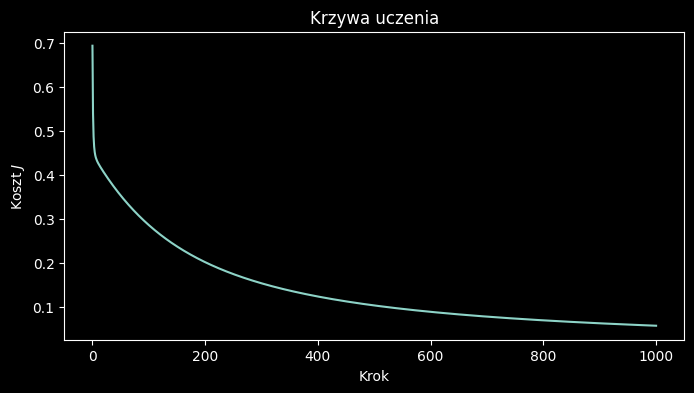

In [17]:
display_logs(logs_logistic_regression, display_every_nth=200)

plot_learning_curve(logs_logistic_regression)


In [18]:
def scalar_logistic_regression_function(theta, x):
    """Funkcja regresji logistycznej (wersja skalarna)"""
    return 1.0/(1.0 + np.exp(-(theta.item(0) + theta.item(1) * x)))

def add_threshold_to_logistic_plot(fig, x_thr):
    """Dodaje próg"""
    ax = fig.axes[0]
    ax.plot([x_thr, x_thr], [-1, 2],
            color='orange', linestyle='dashed',
            label=u'próg: $x={:.2F}$'.format(x_thr))

def add_logistic_regression_to_plot(fig, theta, X):
    """Dodaje wykres krzywej regresji logistycznej"""
    ax = fig.axes[0]
    x0 = np.min(X[:, 1]) - 1.0
    x1 = np.max(X[:, 1]) + 1.0
    Arg = np.arange(x0, x1, 0.1)
    Val = scalar_logistic_regression_function(theta, Arg)
    ax.plot(Arg, Val, linewidth='2')

In [19]:
threshold_logistic = -theta_logistic_regression[0].item() / theta_logistic_regression[1].item()

display(
    Math(
        r'h_{\boldsymbol{\theta}}(x)=0.5 \\'
        r'x\boldsymbol{\theta}=0 \\'
        r'\theta_1 + x \theta_2 = 0 \\'
        f'x = {threshold_logistic:.3f}'
    )
)

<IPython.core.display.Math object>

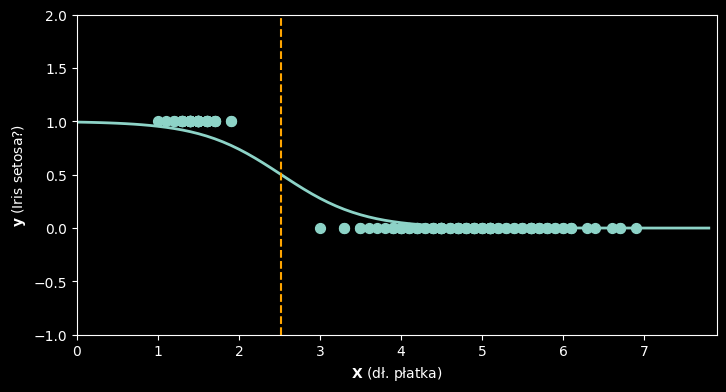

In [20]:
fig = plot_scatter(X, y, '$\mathbf{X}$ (dł. płatka)', '$\mathbf{y}$ (Iris setosa?)')
add_logistic_regression_to_plot(fig, theta_logistic_regression, X)
add_threshold_to_logistic_plot(fig, threshold_logistic)

Traktujemy wartość $h_\theta(x)$ jako prawdopodobieństwo, że cecha przyjmie wartość pozytywną:

$$ h_\theta(x) = P(y = 1 \, \vert \, x; \,\theta) $$

Jeżeli $h_\theta(x) > 0.5$, to dla takiego $x$ będziemy przewidywać wartość $y = 1$.
W przeciwnym wypadku uprzewidzimy $y = 0$.

Dlaczego możemy traktować wartość funkcji regresji logistycznej jako prawdopodobieństwo?

Można o tym poczytać w zewnętrznych źródłach, np. https://towardsdatascience.com/logit-of-logistic-regression-understanding-the-fundamentals-f384152a33d1

### Model -  regresja logistyczna (więcej cech)

Jak postąpić, jeżeli będziemy mieli więcej niż jedną cechę $x$?

Weźmy teraz wszystkie cechy występujące w zbiorze *Iris*.

In [21]:
data_iris_setosa_multi = pd.DataFrame()

data_iris_setosa_multi['dł. płatków'] = data_iris['pl']  # "pl" oznacza "petal length" (długość płatków)
data_iris_setosa_multi['szer. płatków'] = data_iris['pw']  # "pw" oznacza "petal width" (szerokość płatków)
data_iris_setosa_multi['dł. dz. k.'] = data_iris['sl']  # "sl" oznacza "sepal length" (długość działek kielicha)
data_iris_setosa_multi['szer. dz. k.'] = data_iris['sw']  # "sw" oznacza "sepal width" (szerokość działek kielicha)
data_iris_setosa_multi['Iris setosa?'] = data_iris['Gatunek'].apply(lambda x: 1 if x=='Iris-setosa' else 0)

data_iris_setosa_multi[:6]

,dł. płatków,szer. płatków,dł. dz. k.,szer. dz. k.,Iris setosa?
0,1.4,0.2,5.2,3.4,1
1,1.5,0.4,5.1,3.7,1
2,5.6,2.4,6.7,3.1,0
3,5.1,2.0,6.5,3.2,0
4,4.5,1.7,4.9,2.5,0
5,5.1,1.6,6.0,2.7,0


In [22]:
# m, liczba wierszy
m = data_iris_setosa_multi.values.shape[0]

# X, macierz cech o wymiarachach m x n
X = np.matrix(np.hstack([np.ones((m, 1)), data_iris_setosa_multi.values[:, :-1]]))

# y, m-elementowy wektor klas 
y = np.matrix(data_iris_setosa_multi.values[:, -1]).reshape(m, 1)

display(
    Math('\mathbf{X}=' + f'{display_matrix(X)},' + '\quad \mathbf{y}=' + f'{display_matrix(y)}'),
    )

<IPython.core.display.Math object>

In [23]:
# Podział danych na zbiór trenujący i testowy
n_train = 100

X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Macierz parametrów początkowych
thetaTemp = np.ones(5).reshape(5,1)

In [24]:
theta_sigmoid_regression_multi, log_sigmoid_regression_multi = gradient_descent_logistic(
    hypothesis_logistic,
    loss_logistic,
    loss_logistic_derivative,
    thetaTemp,
    X_train,
    y_train, 
    alpha=0.1,
    eps=10**-7,
    maxSteps=1000
)

# Błąd oraz nauczone parametry modelu
display(
    Math(
        '\\mathcal{L}= ' + f'{log_sigmoid_regression_multi[-1][0]:.3f}, '
        f'\\quad \\theta={display_matrix(theta_sigmoid_regression_multi, num_rows=5)}')
)

<IPython.core.display.Math object>

### Funkcja decyzyjna regresji logistycznej

Funkcja decyzyjna mówi o tym, kiedy nasz algorytm będzie przewidywał $y = 1$, a kiedy $y = 0$

$$ c = \left\{ 
\begin{array}{ll}
1, & \text{gdy } \mathbb{P}(y=1 \, | \, x; \theta) > 0.5 \\
0 & \text{w przeciwnym przypadku}
\end{array}\right.
$$

$$ \mathbb{P}(y=1 \,| \, x; \theta) = h_\theta(x) $$

In [25]:
def classifyBi(theta, X):
    prob = hypothesis_logistic(theta, X).item()
    return (1, prob) if prob > 0.5 else (0, prob)

display(
    Math(
        f'\\theta^\\intercal={display_matrix(theta_sigmoid_regression_multi.T, num_rows=5)} \\\\'
        f'x_0 = {display_matrix(X_test[0])} \\\\'
        f"h(x_0) = {hypothesis_logistic(theta_sigmoid_regression_multi, X_test[0]).item()}\\\\"
        f"c(x_0) = {classifyBi(theta_sigmoid_regression_multi, X_test[0])}"
    )
)


<IPython.core.display.Math object>

Obliczmy teraz skuteczność modelu.

In [26]:
acc = 0.0
for i, rest in enumerate(y_test):
    cls, prob = classifyBi(theta_sigmoid_regression_multi, X_test[i])
    if i < 10:
        y_gt = int(y_test[i].item())
        display(Math(f'y_{i}=' + f'{y_gt}, \\quad' + '\\hat{y}' + f'_{i}=' + f'{str(cls)}, \\quad' + '\\mathbb{P}=' + f'{prob:.4f}'))
    acc += cls == y_test[i].item()

print(f"Accuracy: {100* acc / len(X_test)}%")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Accuracy: 100.0%


## 3.2. Wieloklasowa regresja logistyczna

Przykład: wszystkie cechy ze zbioru *Iris*, wszystkie 3 klasy ze zbioru *Iris*.

In [27]:
data_iris = pd.read_csv('iris.csv')
data_iris[:6]

,sl,sw,pl,pw,Gatunek
0,5.2,3.4,1.4,0.2,Iris-setosa
1,5.1,3.7,1.5,0.4,Iris-setosa
2,6.7,3.1,5.6,2.4,Iris-virginica
3,6.5,3.2,5.1,2.0,Iris-virginica
4,4.9,2.5,4.5,1.7,Iris-virginica
5,6.0,2.7,5.1,1.6,Iris-versicolor


In [28]:
# Przygotowanie danych

features = ['sl', 'sw', 'pl', 'pw']
m = len(data_iris)
X = np.matrix(data_iris[features])
X0 = np.ones(m).reshape(m, 1)
X = np.hstack((X0, X))
y = np.matrix(data_iris[["Gatunek"]]).reshape(m, 1)

display(
    Math(
        '\mathbf{X}=' + f'{display_matrix(X)}, \\quad'
        '\mathbf{y}=' + f'{display_matrix(y)}'
    )
)

<IPython.core.display.Math object>

Zamieńmy etykiety tekstowe w tablicy $y$ na wektory jednostkowe (*one-hot vectors*):

$$
\begin{array}{ccc}
\text{"Iris-setosa"}     & \mapsto & \left[ \begin{array}{ccc} 1 & 0 & 0 \\ \end{array} \right] \\
\text{"Iris-virginica"}  & \mapsto & \left[ \begin{array}{ccc} 0 & 1 & 0 \\ \end{array} \right] \\
\text{"Iris-versicolor"} & \mapsto & \left[ \begin{array}{ccc} 0 & 0 & 1 \\ \end{array} \right] \\
\end{array}
$$

Wówczas zamiast wektora $y$ otrzymamy macierz $Y$:

$$
y \; = \;
\left[
\begin{array}{c}
y^{(1)}     \\
y^{(2)}     \\
y^{(3)}     \\
y^{(4)}     \\
y^{(5)}     \\
\vdots      \\
\end{array}
\right]
\; = \;
\left[
\begin{array}{c}
\text{"Iris-setosa"}     \\
\text{"Iris-setosa"}     \\
\text{"Iris-virginica"}  \\
\text{"Iris-versicolor"} \\
\text{"Iris-virginica"}  \\
\vdots                   \\
\end{array}
\right]
\quad \mapsto \quad
Y \; = \;
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
0 & 1 & 0 \\
\vdots & \vdots & \vdots \\
\end{array}
\right]
$$

In [29]:

def mapY(y, cls):
    m = len(y)
    yBi = np.matrix(np.zeros(m)).reshape(m, 1)
    yBi[y == cls] = 1.
    return yBi

def indicatorMatrix(y):
    classes = np.unique(y.tolist())
    m = len(y)
    k = len(classes)
    Y = np.matrix(np.zeros((m, k)))
    for i, cls in enumerate(classes):
        Y[:, i] = mapY(y, cls)
    return Y

# one-hot matrix
Y = indicatorMatrix(y)

display(Math('\mathbf{Y}=' + f'{display_matrix(Y)}'))

<IPython.core.display.Math object>

In [30]:
# to samo, ale szybciej
Y = np.matrix(pd.get_dummies(data_iris['Gatunek']).astype(float).values)

display(Math('\mathbf{Y}=' + f'{display_matrix(Y)}'))


<IPython.core.display.Math object>

In [31]:
display(
    Math('\mathbf{X}=' + f'{display_matrix(X)},' + '\quad \mathbf{Y}=' + f'{display_matrix(Y)}'),
    )

<IPython.core.display.Math object>

In [32]:
# Podział danych na zbiór trenujący i testowy
X_train, X_test = X[:100], X[100:]
y_train, y_test = Y[:100], Y[100:]

# Macierz parametrów początkowych - niech skłąda się z samych jedynek
thetaTemp = np.ones(5).reshape(5,1)

### Od regresji logistycznej dwuklasowej do wieloklasowej

* Irysy są przydzielone do trzech klas: _Iris-setosa_ (0), _Iris-versicolor_ (1), _Iris-virginica_ (2).
* Wiemy, jak stworzyć klasyfikatory dwuklasowe typu _Iris-setosa_ vs. _Nie-Iris-setosa_ (tzw. *one-vs-all*).
* Możemy stworzyć trzy klasyfikatory $h_{\theta_1}, h_{\theta_2}, h_{\theta_3}$ (otrzymując trzy zestawy parametrów $\theta$) i wybrać klasę o najwyższym prawdopodobieństwie.

Pomoże nam w tym funkcja *softmax*, która jest uogólnieniem funkcji logistycznej na większą liczbę wymiarów.

### Funkcja _softmax_

Odpowiednikiem funkcji logistycznej dla wieloklasowej regresji logistycznej jest funkcja $\mathrm{softmax}$:

$$ \textrm{softmax} \colon \mathbb{R}^k \to [0,1]^k $$

$$ \textrm{softmax}(z_1,z_2,\dots,z_k) = \left( \dfrac{e^{z_1}}{\sum_{i=1}^{k}e^{z_i}}, \dfrac{e^{z_2}}{\sum_{i=1}^{k}e^{z_i}}, \ldots, \dfrac{e^{z_k}}{\sum_{i=1}^{k}e^{z_i}} \right) $$

$$ \textrm{softmax}( \left[ \begin{array}{c} \theta_1^T x \\ \theta_2^T x \\ \vdots \\ \theta_k^T x \end{array} \right] ) = \left[ \begin{array}{c} P(y=1 \, | \, x;\theta_1,\ldots,\theta_k) \\ P(y=2 \, | \, x;\theta_1,\ldots,\theta_k) \\ \vdots \\ P(y=k \, | \, x;\theta_1,\ldots,\theta_k) \end{array} \right] $$

In [33]:
# Zapis macierzowy funkcji softmax
def softmax(X):
    return np.exp(X) / np.sum(np.exp(X))

*Dla chętnych:* W praktyce softmax liczy się nieco innym wzorem celem uniknięcia tzw. niedomiaru (ang. underflow).
Poczytaj o [Log-Sum-Exp trick](https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/).

Wartości funkcji $\mathrm{softmax}$ sumują się do 1:

In [34]:
Z = np.matrix([[2.1, 0.5, 0.8, 0.9, 3.2]])
P = softmax(Z)
print(np.sum(P))

0.9999999999999999


In [37]:
# Dla każdej klasy wytrenujmy osobny klasyfikator dwuklasowy.

def trainMaxEnt(X, Y):
    n = X.shape[1]
    thetas = []
    for c in range(Y.shape[1]):
        YBi = Y[:,c]
        theta = np.matrix(np.random.random(n)).reshape(n,1)
        # Macierz parametrów theta obliczona dla każdej klasy osobno.
        thetaBest, errors = gradient_descent_logistic(
            hypothesis_logistic,
            loss_logistic,
            loss_logistic_derivative,
            theta, 
            X,
            YBi,
            alpha=0.1,
            eps=10**-4)
        thetas.append(thetaBest)
    return thetas

# Macierze theta dla każdej klasy
thetas = trainMaxEnt(X_train, y_train)
for c, theta in enumerate(thetas):
    print(f"Otrzymana parametrów dla klasy c={c}:")
    display(
        Math('\\theta_{' + str(c) + '} ' + f'={display_matrix(theta, num_rows=5)}'),
    )

print(f"Całość:")
display(
    Math('\\theta' + f'={display_matrix(np.hstack(thetas), num_rows=5)}'),
)

Otrzymana parametrów dla klasy c=0:


<IPython.core.display.Math object>

Otrzymana parametrów dla klasy c=1:


<IPython.core.display.Math object>

Otrzymana parametrów dla klasy c=2:


<IPython.core.display.Math object>

Całość:


<IPython.core.display.Math object>

### Funkcja decyzyjna wieloklasowej regresji logistycznej

$$ c = \mathop{\textrm{arg}\,\textrm{max}}_{i \in \{1, \ldots ,k\}} P(y=i|x;\theta_1,\ldots,\theta_k) $$

In [36]:
def classify(thetas: List[np.ndarray], X: np.ndarray, debug=False):
    regs = np.array([(X*theta).item() for theta in thetas])
    
    probs = softmax(regs)

    result = np.argmax(probs)
    
    if debug:
        display(
            Math(
                "\\mathbf{x}=" + f"{display_matrix(X_test[i])} \\\\"
                "h_{\\theta}(\\mathbf{x}) = " + f"{display_matrix(regs[:, None].T)}^\\intercal \\\\"
                "\\text{softmax} (h_{\\theta}(\\mathbf{x})) = " + f"{display_matrix(np.around(probs, decimals=3)[:, None].T)}^\\intercal \\\\"
                "\\mathop{\\textrm{arg}\\,\\textrm{max}}_{i \\in \\{1, \\ldots ,k\\}} \\text{softmax} (h_{\\theta}(\\mathbf{x}))_i =" + f"{result}"
                ),
        )
        Math()
    
    return result

for i in range(5):
    YPredicted = classify(thetas, X_test[i], debug=True)
    display(Math(
        "\hat{\mathbf{y}}" + f" = {YPredicted} \\\\"
        "\mathbf{y}" + f" = {np.argmax(y_test[i])}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>